<a href="https://colab.research.google.com/github/lucaslourencodata/eda-idhm-brasil/blob/main/IDHM_2010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xlrd

O que é o IDHM

Links importantes
https://www.undp.org/pt/brazil/o-que-%C3%A9-o-idhm
Base de dados Ipea
https://www.ipea.gov.br/ipeageo/arquivos/bases/IDH_2010.xls

O Índice de Desenvolvimento Humano Municipal (IDHM) é uma medida composta de indicadores de três dimensões do desenvolvimento humano: longevidade, educação e renda. O índice varia de 0 a 1. Quanto mais próximo de 1, maior o desenvolvimento humano.

O IDHM brasileiro segue as mesmas três dimensões do IDH Global - longevidade, educação e renda, mas vai além: adequa a metodologia global ao contexto brasileiro e à disponibilidade de indicadores nacionais. Embora meçam os mesmos fenômenos, os indicadores levados em conta no IDHM são mais adequados para avaliar o desenvolvimento dos municípios brasileiros. Assim, o IDHM - incluindo seus três componentes, IDHM Longevidade, IDHM Educação e IDHM Renda - conta um pouco da história dos municípios em três importantes dimensões do desenvolvimento humano durantes duas décadas da história brasileira.

In [2]:
!pip install xlrd

Pergunta Norteadora: "Quais são os Estados que possuem um bom IDH para que possamos entregar bons produtos."

In [3]:
!pip install plotly
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn

In [4]:
# Libs - Exploração Manipulação de Dados
import pandas as pd
import numpy as np

#Libs Gráfico
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Avisos
import warnings
warnings.filterwarnings('ignore')


In [5]:
idhm = pd.read_excel('IDH_2010.xls')

In [6]:
idhm.head()

,ANO,Código da Unidade da Federação,Nome da Unidade da Federação,Código do Município,Município,Esperança de vida ao nascer,Taxa de fecundidade total,Mortalidade infantil,Mortalidade até 5 anos de idade,Razão de dependência,...,População de 15 a 17 anos.1,População de 18 anos ou mais.1,População total em domicílios particulares permanentes,"População total em domicílios particulares permanentes, exceto com renda nula",Subíndice de escolaridade - IDHM Educação,Subíndice de frequência escolar - IDHM Educação,IDHM,IDHM Educação,IDHM Longevidade,IDHM Renda
0,2010,11,Rondônia,110001,ALTA FLORESTA D'OESTE,70.75,2.24,23.8,25.49,47.37,...,1602,16431,24097,22429,0.368,0.629,0.641,0.526,0.763,0.657
1,2010,11,Rondônia,110002,ARIQUEMES,73.36,1.91,19.2,20.53,46.68,...,5256,60213,89766,88730,0.514,0.648,0.702,0.600,0.806,0.716
2,2010,11,Rondônia,110003,CABIXI,70.39,2.15,24.8,26.58,48.12,...,381,4306,6303,6156,0.357,0.700,0.650,0.559,0.757,0.650
3,2010,11,Rondônia,110004,CACOAL,74.27,1.90,14.3,15.38,43.79,...,4547,54356,78141,76876,0.488,0.698,0.718,0.620,0.821,0.727
4,2010,11,Rondônia,110005,CEREJEIRAS,72.94,2.12,18.1,19.42,45.67,...,1033,11786,16942,16815,0.430,0.712,0.692,0.602,0.799,0.688


## Tamanho da Base de Dados

In [7]:
idhm.shape

(5564, 237)

In [8]:
print(f'Tamanho do nosso dataset (Linhas, Colunas): {idhm.shape}')

Tamanho do nosso dataset (Linhas, Colunas): (5564, 237)


Verificar os tipos dos dados

In [9]:
idhm.dtypes

,0
ANO,int64
Código da Unidade da Federação,int64
Nome da Unidade da Federação,object
Código do Município,int64
Município,object
...,...
Subíndice de frequência escolar - IDHM Educação,float64
IDHM,float64
IDHM Educação,float64
IDHM Longevidade,float64


Existe Valores Nulos?

In [10]:
dados_nulos = idhm.isnull().sum().sum()

In [11]:
print(f'Quantidade de valores nulos no nosso dataframe: {idhm.isnull().sum().sum()}')

Quantidade de valores nulos no nosso dataframe: 0


In [12]:
print(f'Quantidade de valores nulos no nosso dataframe: {dados_nulos}')

Quantidade de valores nulos no nosso dataframe: 0


In [13]:
idhm.columns

Index(['ANO', 'Código da Unidade da Federação', 'Nome da Unidade da Federação',
       'Código do Município', 'Município', 'Esperança de vida ao nascer',
       'Taxa de fecundidade total', 'Mortalidade infantil',
       'Mortalidade até 5 anos de idade', 'Razão de dependência',
       ...
       'População de 15 a 17 anos.1', 'População de 18 anos ou mais.1',
       'População total em domicílios particulares permanentes',
       'População total em domicílios particulares permanentes, exceto com renda nula',
       'Subíndice de escolaridade - IDHM Educação',
       'Subíndice de frequência escolar - IDHM Educação', 'IDHM',
       'IDHM Educação', 'IDHM Longevidade', 'IDHM Renda'],
      dtype='object', length=237)

In [14]:
df_idhm = idhm[['Nome da Unidade da Federação', 'Município', 'IDHM', 'IDHM Educação', 'IDHM Longevidade', 'IDHM Renda']]

In [15]:
df_idhm.head()

,Nome da Unidade da Federação,Município,IDHM,IDHM Educação,IDHM Longevidade,IDHM Renda
0,Rondônia,ALTA FLORESTA D'OESTE,0.641,0.526,0.763,0.657
1,Rondônia,ARIQUEMES,0.702,0.600,0.806,0.716
2,Rondônia,CABIXI,0.650,0.559,0.757,0.650
3,Rondônia,CACOAL,0.718,0.620,0.821,0.727
4,Rondônia,CEREJEIRAS,0.692,0.602,0.799,0.688


In [16]:
df_idhm.columns = ['uf', 'municipio', 'idhm', 'idhm_educacao', 'idhm_longevidade', 'idhm_renda']

In [17]:
df_idhm.head()

,uf,municipio,idhm,idhm_educacao,idhm_longevidade,idhm_renda
0,Rondônia,ALTA FLORESTA D'OESTE,0.641,0.526,0.763,0.657
1,Rondônia,ARIQUEMES,0.702,0.600,0.806,0.716
2,Rondônia,CABIXI,0.650,0.559,0.757,0.650
3,Rondônia,CACOAL,0.718,0.620,0.821,0.727
4,Rondônia,CEREJEIRAS,0.692,0.602,0.799,0.688


In [18]:
df_idhm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5564 entries, 0 to 5563
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uf                5564 non-null   object 
 1   municipio         5564 non-null   object 
 2   idhm              5564 non-null   float64
 3   idhm_educacao     5564 non-null   float64
 4   idhm_longevidade  5564 non-null   float64
 5   idhm_renda        5564 non-null   float64
dtypes: float64(4), object(2)
memory usage: 260.9+ KB


Valores Únicos

In [19]:
df_idhm.nunique()

,0
uf,27
municipio,5329
idhm,349
idhm_educacao,466
idhm_longevidade,220
idhm_renda,390


Estatística Descritiva

In [20]:
df_idhm.describe().round(2)

,idhm,idhm_educacao,idhm_longevidade,idhm_renda
count,5564.00,5564.00,5564.00,5564.00
mean,0.66,0.56,0.80,0.64
std,0.07,0.09,0.04,0.08
min,0.42,0.21,0.67,0.40
25%,0.60,0.49,0.77,0.57
50%,0.66,0.56,0.81,0.65
75%,0.72,0.63,0.84,0.71
max,0.86,0.82,0.89,0.89


Primeira análise

0 - 0,499 - Baixo Desenvolvimento Humano
0,5 - 0,799 - Médio Desenvolvimento Humano
0,8 - 1 - Alto Desenvolvimento Humano

In [21]:
df_idhm['idhm']

,idhm
0,0.641
1,0.702
2,0.650
3,0.718
4,0.692
...,...
5559,0.712
5560,0.684
5561,0.647
5562,0.634


In [22]:
#Função Classificação IDHM
def idhm_class(df):
  if df['idhm'] <= 0.499:
    return 'Baixo Desenvolvimento Humano'
  elif df['idhm'] >= 0.8:
    return 'Alto Desenvolvimento Humano'
  else:
    return 'Médio Desenvolvimento Humano'

In [23]:
df_idhm['classe'] = df_idhm.apply(idhm_class, axis=1)
df_idhm

,uf,municipio,idhm,idhm_educacao,idhm_longevidade,idhm_renda,classe
0,Rondônia,ALTA FLORESTA D'OESTE,0.641,0.526,0.763,0.657,Médio Desenvolvimento Humano
1,Rondônia,ARIQUEMES,0.702,0.600,0.806,0.716,Médio Desenvolvimento Humano
2,Rondônia,CABIXI,0.650,0.559,0.757,0.650,Médio Desenvolvimento Humano
3,Rondônia,CACOAL,0.718,0.620,0.821,0.727,Médio Desenvolvimento Humano
4,Rondônia,CEREJEIRAS,0.692,0.602,0.799,0.688,Médio Desenvolvimento Humano
...,...,...,...,...,...,...,...
5559,Goiás,VIANÓPOLIS,0.712,0.622,0.818,0.710,Médio Desenvolvimento Humano
5560,Goiás,VICENTINÓPOLIS,0.684,0.562,0.804,0.707,Médio Desenvolvimento Humano
5561,Goiás,VILA BOA,0.647,0.534,0.818,0.619,Médio Desenvolvimento Humano
5562,Goiás,VILA PROPÍCIO,0.634,0.505,0.802,0.629,Médio Desenvolvimento Humano


In [24]:
df_idhm.head(20)

,uf,municipio,idhm,idhm_educacao,idhm_longevidade,idhm_renda,classe
0,Rondônia,ALTA FLORESTA D'OESTE,0.641,0.526,0.763,0.657,Médio Desenvolvimento Humano
1,Rondônia,ARIQUEMES,0.702,0.600,0.806,0.716,Médio Desenvolvimento Humano
2,Rondônia,CABIXI,0.650,0.559,0.757,0.650,Médio Desenvolvimento Humano
3,Rondônia,CACOAL,0.718,0.620,0.821,0.727,Médio Desenvolvimento Humano
4,Rondônia,CEREJEIRAS,0.692,0.602,0.799,0.688,Médio Desenvolvimento Humano
5,Rondônia,COLORADO DO OESTE,0.685,0.584,0.814,0.676,Médio Desenvolvimento Humano
6,Rondônia,CORUMBIARA,0.613,0.473,0.774,0.630,Médio Desenvolvimento Humano
7,Rondônia,COSTA MARQUES,0.611,0.493,0.751,0.616,Médio Desenvolvimento Humano
8,Rondônia,ESPIGÃO D'OESTE,0.672,0.536,0.819,0.691,Médio Desenvolvimento Humano
9,Rondônia,GUAJARÁ-MIRIM,0.657,0.519,0.823,0.663,Médio Desenvolvimento Humano


In [25]:
df_idhm['classe'].value_counts()

,count
classe,
Médio Desenvolvimento Humano,5488
Alto Desenvolvimento Humano,44
Baixo Desenvolvimento Humano,32


Pairplot

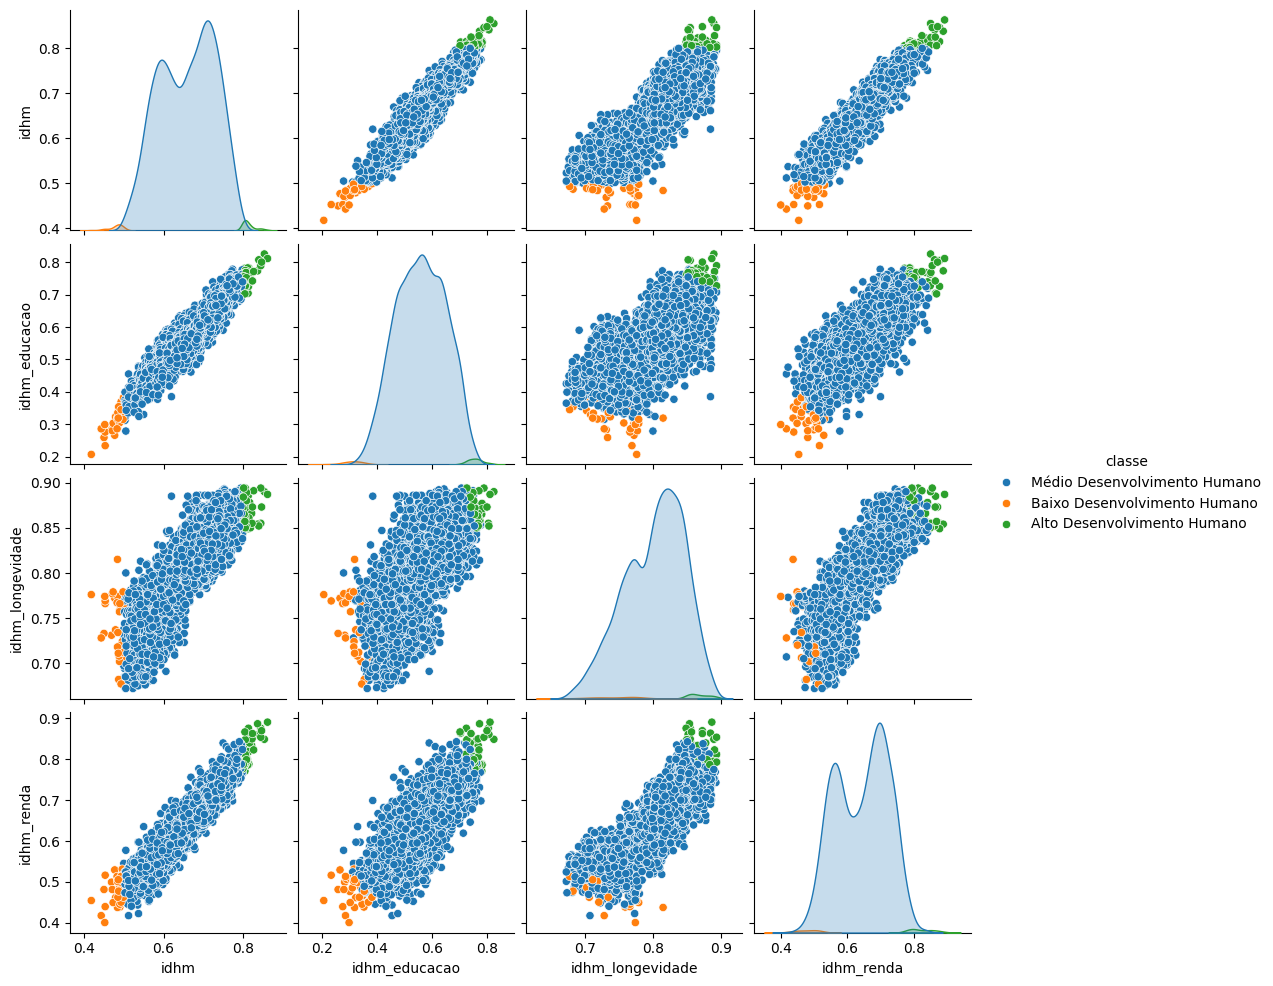

In [26]:
sns.pairplot(df_idhm, hue='classe')

Interessante observar a relação entre a renda e a escolaridade. Parece ter relação

Análise por estado

In [27]:
df_idhm_estado = pd.DataFrame(df_idhm.groupby('uf')['idhm'].mean().round(2)).reset_index()

In [28]:
df_idhm_estado

,uf,idhm
0,Acre,0.59
1,Alagoas,0.56
2,Amapá,0.64
3,Amazonas,0.57
4,Bahia,0.59
5,Ceará,0.62
6,Distrito Federal,0.82
7,Espírito Santo,0.69
8,Goiás,0.69
9,Maranhão,0.58


In [29]:
df_idhm_estado['classe'] = df_idhm_estado.apply(idhm_class, axis=1)

In [30]:
df_idhm_estado

,uf,idhm,classe
0,Acre,0.59,Médio Desenvolvimento Humano
1,Alagoas,0.56,Médio Desenvolvimento Humano
2,Amapá,0.64,Médio Desenvolvimento Humano
3,Amazonas,0.57,Médio Desenvolvimento Humano
4,Bahia,0.59,Médio Desenvolvimento Humano
5,Ceará,0.62,Médio Desenvolvimento Humano
6,Distrito Federal,0.82,Alto Desenvolvimento Humano
7,Espírito Santo,0.69,Médio Desenvolvimento Humano
8,Goiás,0.69,Médio Desenvolvimento Humano
9,Maranhão,0.58,Médio Desenvolvimento Humano


In [31]:
df_idhm_estado['classe'].value_counts()

,count
classe,
Médio Desenvolvimento Humano,26
Alto Desenvolvimento Humano,1


In [32]:
df_idhm_estado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   uf      27 non-null     object 
 1   idhm    27 non-null     float64
 2   classe  27 non-null     object 
dtypes: float64(1), object(2)
memory usage: 780.0+ bytes


Estatística Descritia dos Estados quanto ao IDHM Geral

In [33]:
df_idhm_estado.describe().round(2)

,idhm
count,27.00
mean,0.64
std,0.06
min,0.56
25%,0.59
50%,0.64
75%,0.69
max,0.82


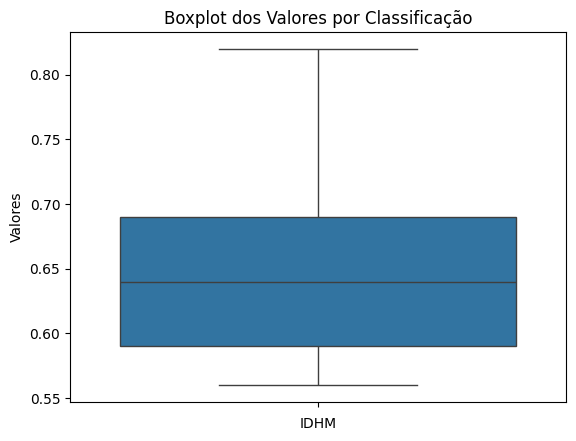

In [34]:
# Usando o seaborn para gráfico de boxplot
sns.boxplot(y = df_idhm_estado['idhm'], data = df_idhm_estado)

# Adicionar título e rótulos para eixos.
plt.title('Boxplot dos Valores por Classificação')
plt.xlabel('IDHM')
plt.ylabel('Valores')

plt.show()

### Criar um gráfico de barra

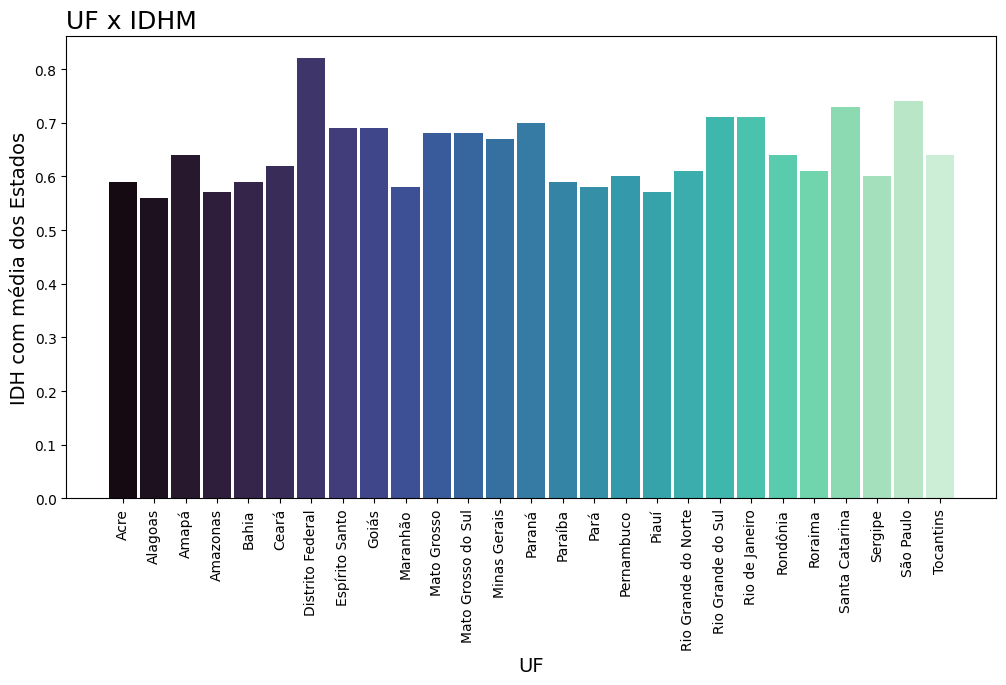

In [35]:
# Tamanho da figura
plt.figure(figsize=(12, 6))

# Paleta de Cores
Paleta_Cores = sns.color_palette('mako', len(df_idhm_estado))

# Plotagem
plt.bar(df_idhm_estado['uf'],
        df_idhm_estado['idhm'],
        width=0.9,
        color = Paleta_Cores
        )

# Titulo
plt.title('UF x IDHM', loc = 'left', fontsize=18)

# Labels
plt.xlabel('UF', fontsize = 14)
plt.ylabel('IDH com média dos Estados', fontsize = 14)
plt.xticks(rotation = 90);

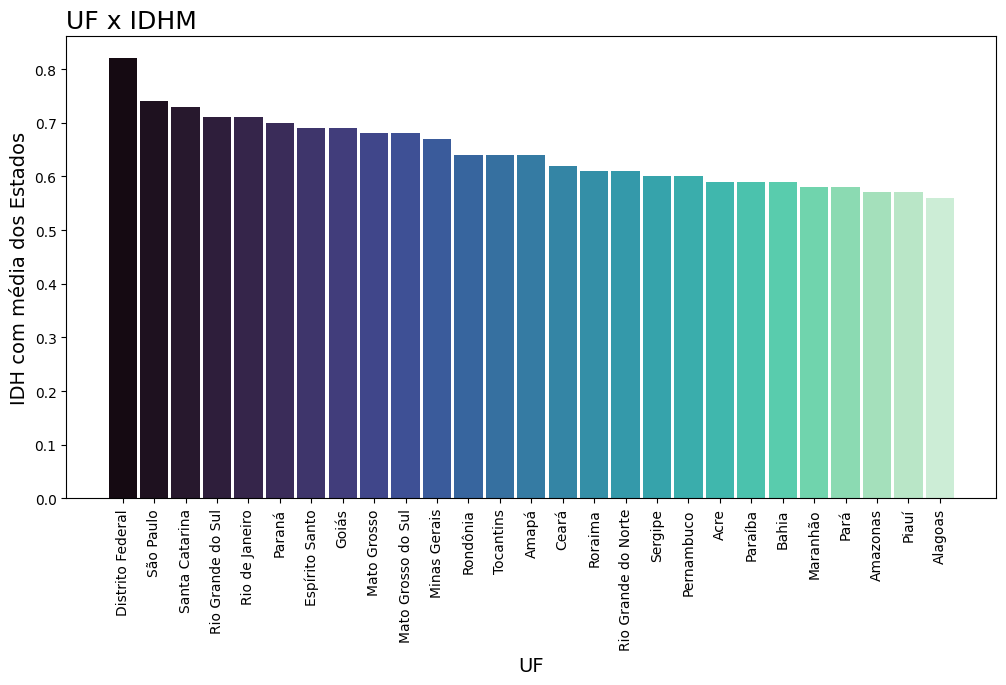

In [36]:
df_idhm_estado = df_idhm_estado.sort_values(by='idhm', ascending=False)

# Tamanho da figura
plt.figure(figsize=(12, 6))

# Paleta de Cores
Paleta_Cores = sns.color_palette('mako', len(df_idhm_estado))

# Plotagem
plt.bar(df_idhm_estado['uf'],
        df_idhm_estado['idhm'],
        width=0.9,
        color = Paleta_Cores
        )

# Titulo
plt.title('UF x IDHM', loc = 'left', fontsize=18)

# Labels
plt.xlabel('UF', fontsize = 14)
plt.ylabel('IDH com média dos Estados', fontsize = 14)
plt.xticks(rotation = 90);

In [37]:
df_idhm_estado.head(10)

,uf,idhm,classe
6,Distrito Federal,0.82,Alto Desenvolvimento Humano
25,São Paulo,0.74,Médio Desenvolvimento Humano
23,Santa Catarina,0.73,Médio Desenvolvimento Humano
19,Rio Grande do Sul,0.71,Médio Desenvolvimento Humano
20,Rio de Janeiro,0.71,Médio Desenvolvimento Humano
13,Paraná,0.70,Médio Desenvolvimento Humano
7,Espírito Santo,0.69,Médio Desenvolvimento Humano
8,Goiás,0.69,Médio Desenvolvimento Humano
10,Mato Grosso,0.68,Médio Desenvolvimento Humano
11,Mato Grosso do Sul,0.68,Médio Desenvolvimento Humano


In [38]:
# Criar um gráfico de barras usando o Plotly
fig = px.bar(df_idhm_estado,
             x='uf',
             y='idhm',
             color='classe',
             title='IDHM por Estado',
             color_discrete_sequence=['green', 'orange']
)

fig.show()

In [39]:
# Usando o Plotly para Treemap
fig = px.treemap(df_idhm_estado,
                 path=['uf'],
                 values='idhm',
)

fig.show()

In [40]:
#Fitro
df_idhm_estado = pd.DataFrame(df_idhm.groupby('uf')[['idhm','idhm_educacao', 'idhm_longevidade','idhm_renda']].mean().round(2)).reset_index()

In [41]:
df_idhm_estado

,uf,idhm,idhm_educacao,idhm_longevidade,idhm_renda
0,Acre,0.59,0.45,0.77,0.59
1,Alagoas,0.56,0.44,0.74,0.55
2,Amapá,0.64,0.55,0.78,0.62
3,Amazonas,0.57,0.44,0.77,0.55
4,Bahia,0.59,0.48,0.76,0.57
5,Ceará,0.62,0.55,0.76,0.56
6,Distrito Federal,0.82,0.74,0.87,0.86
7,Espírito Santo,0.69,0.59,0.83,0.68
8,Goiás,0.69,0.60,0.83,0.68
9,Maranhão,0.58,0.49,0.74,0.53


In [42]:
df_idhm_estado['classe'] = df_idhm_estado.apply(idhm_class, axis=1)

In [43]:
df_idhm_estado

,uf,idhm,idhm_educacao,idhm_longevidade,idhm_renda,classe
0,Acre,0.59,0.45,0.77,0.59,Médio Desenvolvimento Humano
1,Alagoas,0.56,0.44,0.74,0.55,Médio Desenvolvimento Humano
2,Amapá,0.64,0.55,0.78,0.62,Médio Desenvolvimento Humano
3,Amazonas,0.57,0.44,0.77,0.55,Médio Desenvolvimento Humano
4,Bahia,0.59,0.48,0.76,0.57,Médio Desenvolvimento Humano
5,Ceará,0.62,0.55,0.76,0.56,Médio Desenvolvimento Humano
6,Distrito Federal,0.82,0.74,0.87,0.86,Alto Desenvolvimento Humano
7,Espírito Santo,0.69,0.59,0.83,0.68,Médio Desenvolvimento Humano
8,Goiás,0.69,0.60,0.83,0.68,Médio Desenvolvimento Humano
9,Maranhão,0.58,0.49,0.74,0.53,Médio Desenvolvimento Humano


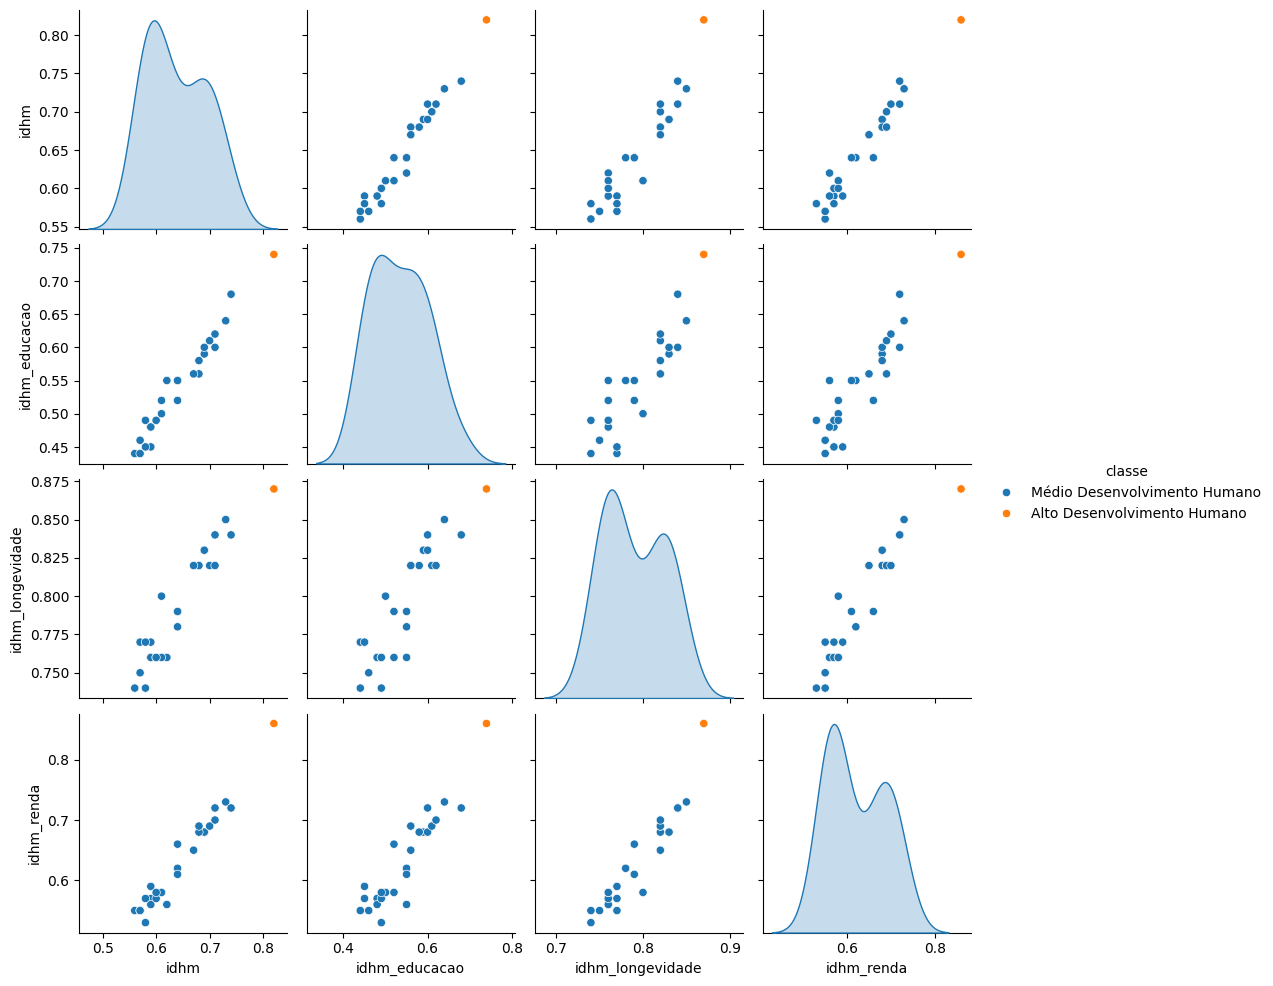

In [44]:
sns.pairplot(df_idhm_estado, hue='classe')

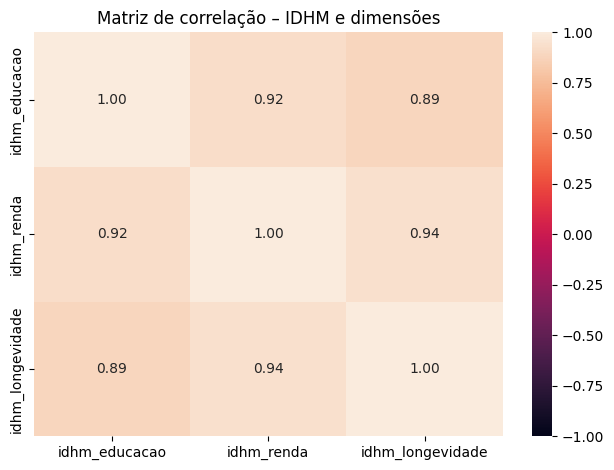

In [45]:
# Heatmap
cols_corr = [c for c in ["idhm_educacao", "idhm_renda", "idhm_longevidade"] if c in df_idhm.columns]
corr = df_idhm_estado[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – IDHM e dimensões")
plt.tight_layout()
plt.show()

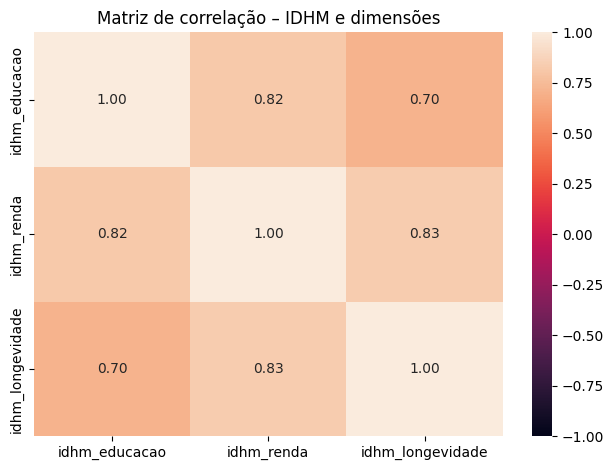

In [46]:
cols_corr = [c for c in ["idhm_educacao", "idhm_renda", "idhm_longevidade"] if c in df_idhm.columns] #municípios
corr = df_idhm[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – IDHM e dimensões")
plt.tight_layout()
plt.show()

In [47]:
#Estado
df_idhm_estado.describe().round(2)

,idhm,idhm_educacao,idhm_longevidade,idhm_renda
count,27.00,27.00,27.00,27.00
mean,0.64,0.54,0.79,0.63
std,0.06,0.08,0.04,0.08
min,0.56,0.44,0.74,0.53
25%,0.59,0.48,0.76,0.57
50%,0.64,0.55,0.79,0.61
75%,0.69,0.60,0.82,0.68
max,0.82,0.74,0.87,0.86


In [48]:
#Município
df_idhm.describe().round(2)

,idhm,idhm_educacao,idhm_longevidade,idhm_renda
count,5564.00,5564.00,5564.00,5564.00
mean,0.66,0.56,0.80,0.64
std,0.07,0.09,0.04,0.08
min,0.42,0.21,0.67,0.40
25%,0.60,0.49,0.77,0.57
50%,0.66,0.56,0.81,0.65
75%,0.72,0.63,0.84,0.71
max,0.86,0.82,0.89,0.89


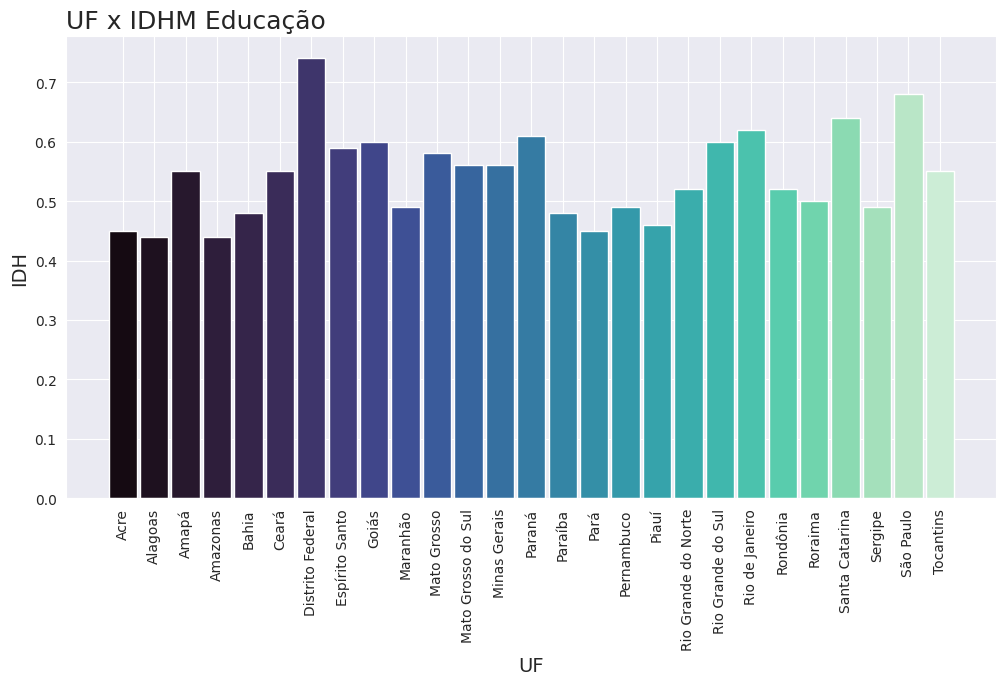

In [49]:
#Tamanho da Figura
plt.figure(figsize=(12,6))

#Paleta de Cores
Paleta_Cores = sns.color_palette('mako', len(df_idhm_estado) )
sns.set_style('darkgrid')

#Plotagem
plt.bar(df_idhm_estado['uf'],
        df_idhm_estado['idhm_educacao'],
        width=0.9,
        color = Paleta_Cores
        )

#Titulo
plt.title('UF x IDHM Educação', loc = 'left', fontsize = 18)

#Labels
plt.xlabel('UF', fontsize = 14)
plt.ylabel('IDH', fontsize = 14)
plt.xticks(rotation = 90);

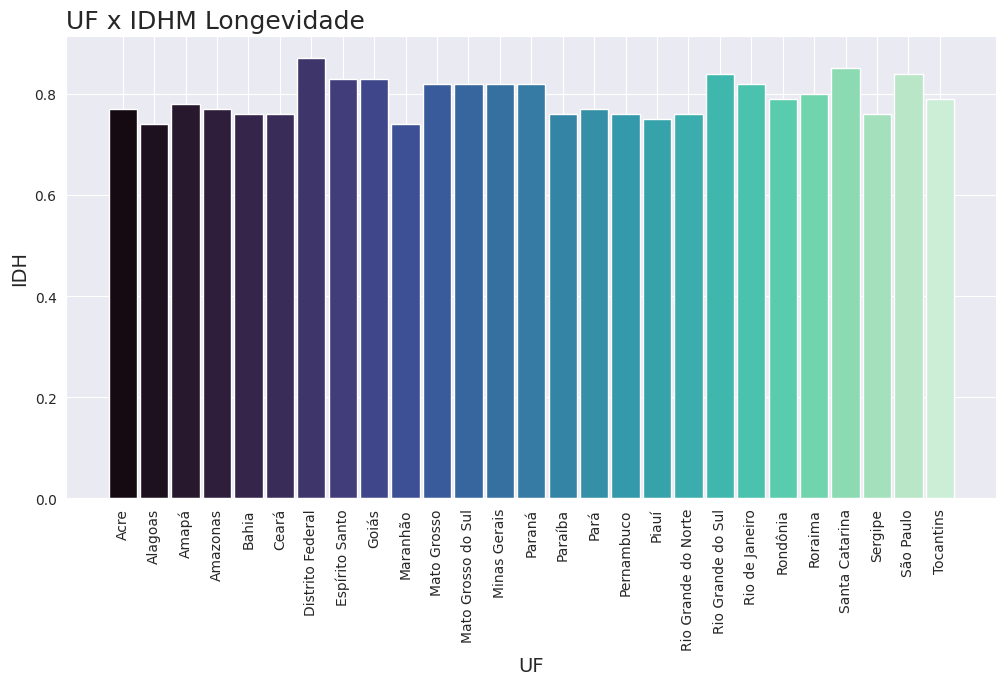

In [50]:
#Tamanho da Figura
plt.figure(figsize=(12,6))

#Paleta de Cores
Paleta_Cores = sns.color_palette('mako', len(df_idhm_estado) )
sns.set_style('darkgrid')

#Plotagem
plt.bar(df_idhm_estado['uf'],
        df_idhm_estado['idhm_longevidade'],
        width=0.9,
        color = Paleta_Cores
        )

#Titulo
plt.title('UF x IDHM Longevidade', loc = 'left', fontsize = 18)

#Labels
plt.xlabel('UF', fontsize = 14)
plt.ylabel('IDH', fontsize = 14)
plt.xticks(rotation = 90);

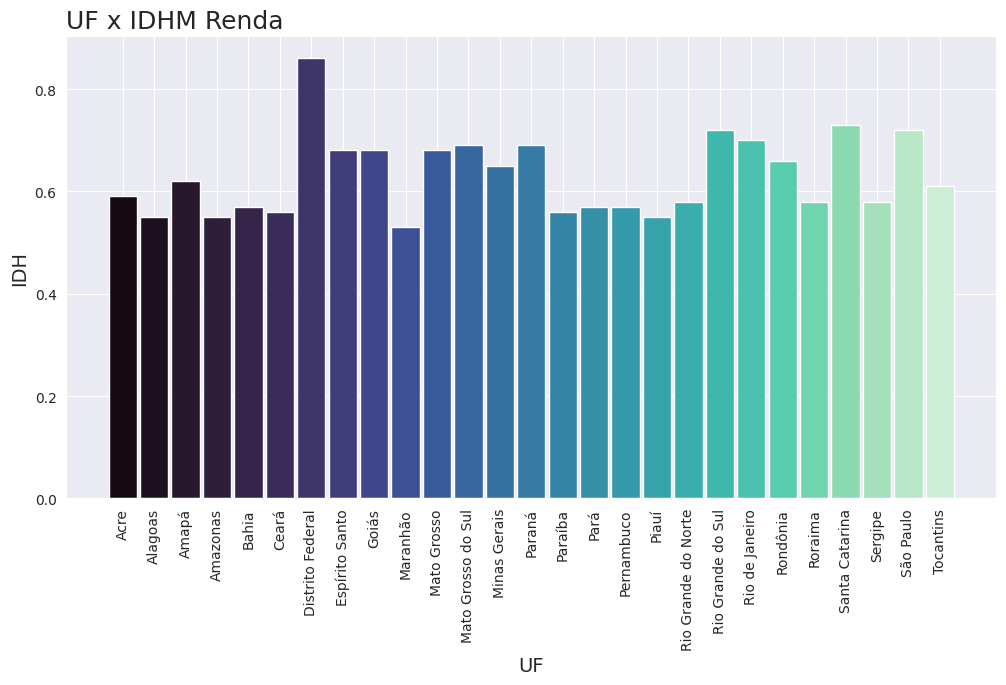

In [51]:
#Tamanho da Figura
plt.figure(figsize=(12,6))

#Paleta de Cores
Paleta_Cores = sns.color_palette('mako', len(df_idhm_estado))
sns.set_style('darkgrid')

#Plotagem
plt.bar(df_idhm_estado['uf'],
        df_idhm_estado['idhm_renda'],
        width=0.9,
        color = Paleta_Cores
        )

#Titulo
plt.title('UF x IDHM Renda', loc = 'left', fontsize = 18)

#Labels
plt.xlabel('UF', fontsize = 14)
plt.ylabel('IDH', fontsize = 14)
plt.xticks(rotation = 90);

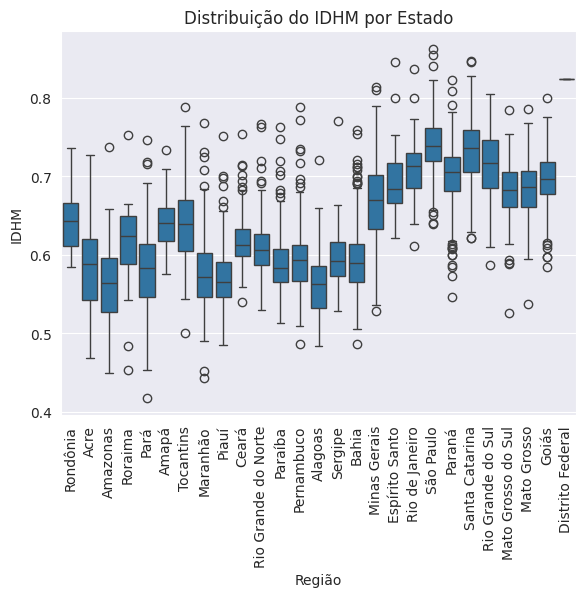

In [52]:
#Boxsplot por estado
plt.figure()
sns.boxplot(data=df_idhm, x="uf", y="idhm") #municipio
plt.title("Distribuição do IDHM por Estado")
plt.xlabel("Região")
plt.ylabel("IDHM")
plt.tight_layout()
plt.xticks(rotation = 90);
plt.show()

In [53]:
# Mapeando nome do estado -> região

mapa_regiao_nome = {
    "Acre": "Norte",
    "Amapá": "Norte",
    "Amazonas": "Norte",
    "Pará": "Norte",
    "Rondônia": "Norte",
    "Roraima": "Norte",
    "Tocantins": "Norte",

    "Alagoas": "Nordeste",
    "Bahia": "Nordeste",
    "Ceará": "Nordeste",
    "Maranhão": "Nordeste",
    "Paraíba": "Nordeste",
    "Pernambuco": "Nordeste",
    "Piauí": "Nordeste",
    "Rio Grande do Norte": "Nordeste",
    "Sergipe": "Nordeste",

    "Distrito Federal": "Centro-Oeste",
    "Goiás": "Centro-Oeste",
    "Mato Grosso": "Centro-Oeste",
    "Mato Grosso do Sul": "Centro-Oeste",

    "Espírito Santo": "Sudeste",
    "Minas Gerais": "Sudeste",
    "Rio de Janeiro": "Sudeste",
    "São Paulo": "Sudeste",

    "Paraná": "Sul",
    "Rio Grande do Sul": "Sul",
    "Santa Catarina": "Sul",
}

df_idhm["regiao"] = df_idhm["uf"].map(mapa_regiao_nome) # MUNÍCIPIO

df_idhm[["uf", "regiao"]].drop_duplicates().sort_values("regiao")

,uf,regiao
5563,Distrito Federal,Centro-Oeste
5176,Mato Grosso,Centro-Oeste
5098,Mato Grosso do Sul,Centro-Oeste
5317,Goiás,Centro-Oeste
1825,Bahia,Nordeste
1750,Sergipe,Nordeste
1463,Pernambuco,Nordeste
1240,Paraíba,Nordeste
1073,Rio Grande do Norte,Nordeste
1648,Alagoas,Nordeste


In [54]:
df_idhm.head()

,uf,municipio,idhm,idhm_educacao,idhm_longevidade,idhm_renda,classe,regiao
0,Rondônia,ALTA FLORESTA D'OESTE,0.641,0.526,0.763,0.657,Médio Desenvolvimento Humano,Norte
1,Rondônia,ARIQUEMES,0.702,0.600,0.806,0.716,Médio Desenvolvimento Humano,Norte
2,Rondônia,CABIXI,0.650,0.559,0.757,0.650,Médio Desenvolvimento Humano,Norte
3,Rondônia,CACOAL,0.718,0.620,0.821,0.727,Médio Desenvolvimento Humano,Norte
4,Rondônia,CEREJEIRAS,0.692,0.602,0.799,0.688,Médio Desenvolvimento Humano,Norte


In [55]:
idhm_regiao = df_idhm.groupby("regiao")["idhm"].mean().sort_values()

In [56]:
idhm_regiao

,idhm
regiao,
Nordeste,0.590672
Norte,0.607951
Centro-Oeste,0.689468
Sudeste,0.698984
Sul,0.714113


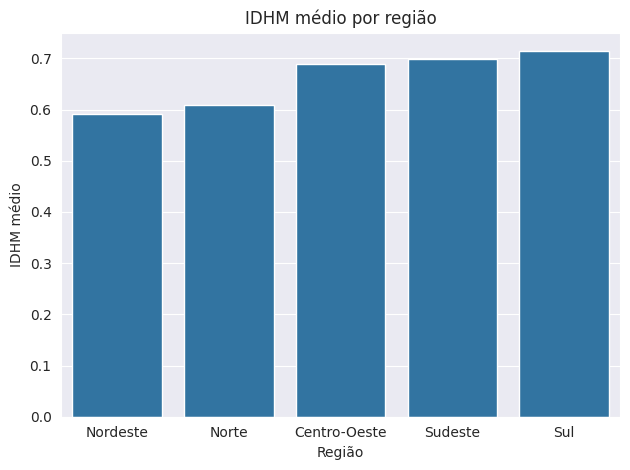

In [57]:
plt.figure()
sns.barplot(x=idhm_regiao.index, y=idhm_regiao.values)
plt.title("IDHM médio por região")
plt.xlabel("Região")
plt.ylabel("IDHM médio")
plt.tight_layout()
plt.show()

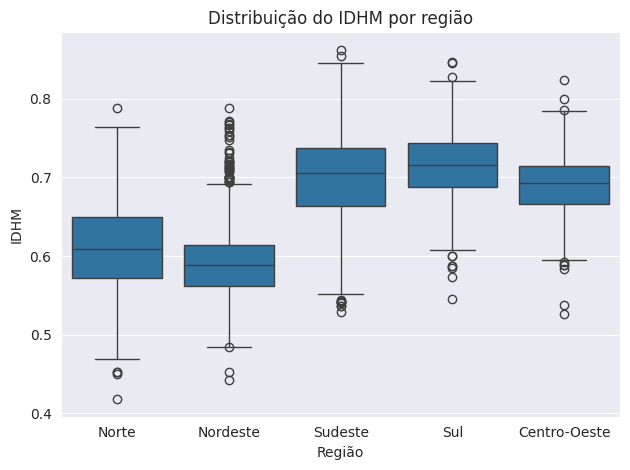

In [58]:
plt.figure()
sns.boxplot(data=df_idhm, x="regiao", y="idhm") #municipio
plt.title("Distribuição do IDHM por região")
plt.xlabel("Região")
plt.ylabel("IDHM")
plt.tight_layout()
plt.show()

In [59]:
# 9.1 Maiores e Menores N municípios por IDHM

N = 10

if "municipio" in df_idhm.columns:
    maiores = df_idhm.sort_values("idhm", ascending=False).head(N)[["municipio", "uf", "idhm","regiao"]].copy()
    menores = df_idhm.sort_values("idhm", ascending=True).head(N)[["municipio", "uf", "idhm","regiao"]].copy()
else:
    maiores = df_idhm.sort_values("idhm", ascending=False).head(N)[["uf", "idhm"]].copy()
    menores = df_idhm.sort_values("idhm", ascending=True).head(N)[["uf", "idhm"]].copy()

# Criar coluna indicando se é Top ou Bottom
maiores["tipo"] = "Maiores"
menores["tipo"] = "Menores"

# Unir tudo em um único DataFrame
ranking_idhm = pd.concat([maiores, menores], axis=0).reset_index(drop=True)

ranking_idhm

,municipio,uf,idhm,regiao,tipo
0,SÃO CAETANO DO SUL,São Paulo,0.862,Sudeste,Maiores
1,ÁGUAS DE SÃO PEDRO,São Paulo,0.854,Sudeste,Maiores
2,FLORIANÓPOLIS,Santa Catarina,0.847,Sul,Maiores
3,VITÓRIA,Espírito Santo,0.845,Sudeste,Maiores
4,BALNEÁRIO CAMBORIÚ,Santa Catarina,0.845,Sul,Maiores
5,SANTOS,São Paulo,0.840,Sudeste,Maiores
6,NITERÓI,Rio de Janeiro,0.837,Sudeste,Maiores
7,JOAÇABA,Santa Catarina,0.827,Sul,Maiores
8,BRASÍLIA,Distrito Federal,0.824,Centro-Oeste,Maiores
9,CURITIBA,Paraná,0.823,Sul,Maiores


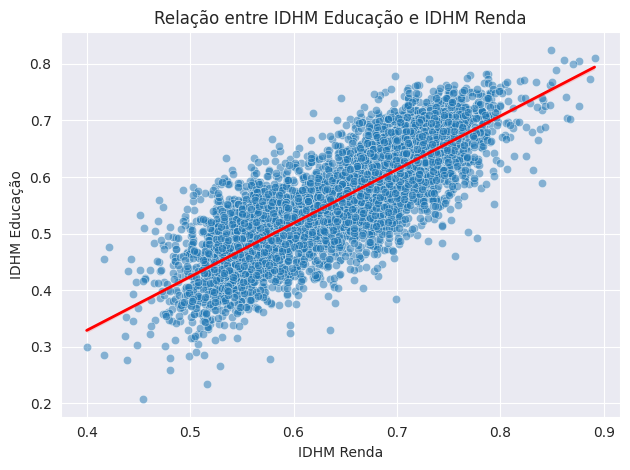

In [60]:
sns.scatterplot(data=df_idhm, x="idhm_renda", y="idhm_educacao", alpha=0.5)

# Linha de tendência com regplot
sns.regplot(
         data=df_idhm,
        x="idhm_renda",
        y="idhm_educacao",
        scatter=False,            # não recria os pontos
        color="red",              # linha de tendência em vermelho
        line_kws={"linewidth": 2} # deixa a linha mais grossa
    )

plt.title("Relação entre IDHM Educação e IDHM Renda")
plt.xlabel("IDHM Renda")
plt.ylabel("IDHM Educação")
plt.tight_layout()
plt.show()

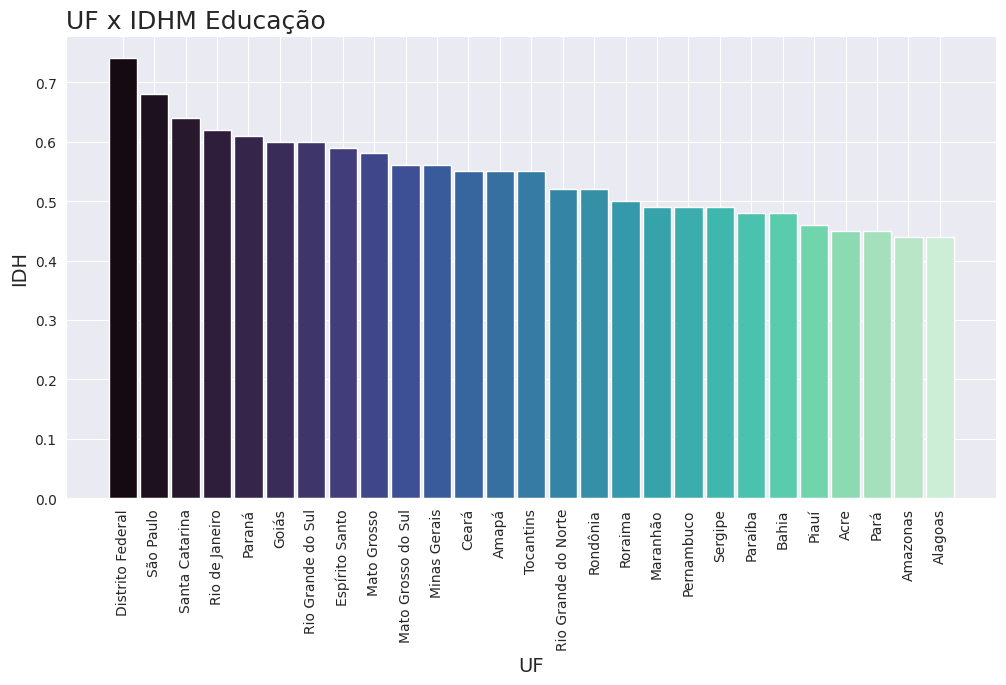

In [61]:
# Ordenar os dados do maior para o menor número de infecções
df_idhm_estado = df_idhm_estado.sort_values(by="idhm_educacao", ascending=False)

#Tamanho da Figura
plt.figure(figsize=(12,6))

#Paleta de Cores
Paleta_Cores = sns.color_palette('mako', len(df_idhm_estado) )
sns.set_style('darkgrid')

#Plotagem
plt.bar(df_idhm_estado['uf'],
        df_idhm_estado['idhm_educacao'],
        width=0.9,
        color = Paleta_Cores
        )

#Titulo
plt.title('UF x IDHM Educação', loc = 'left', fontsize = 18)

#Labels
plt.xlabel('UF', fontsize = 14)
plt.ylabel('IDH', fontsize = 14)
plt.xticks(rotation = 90);

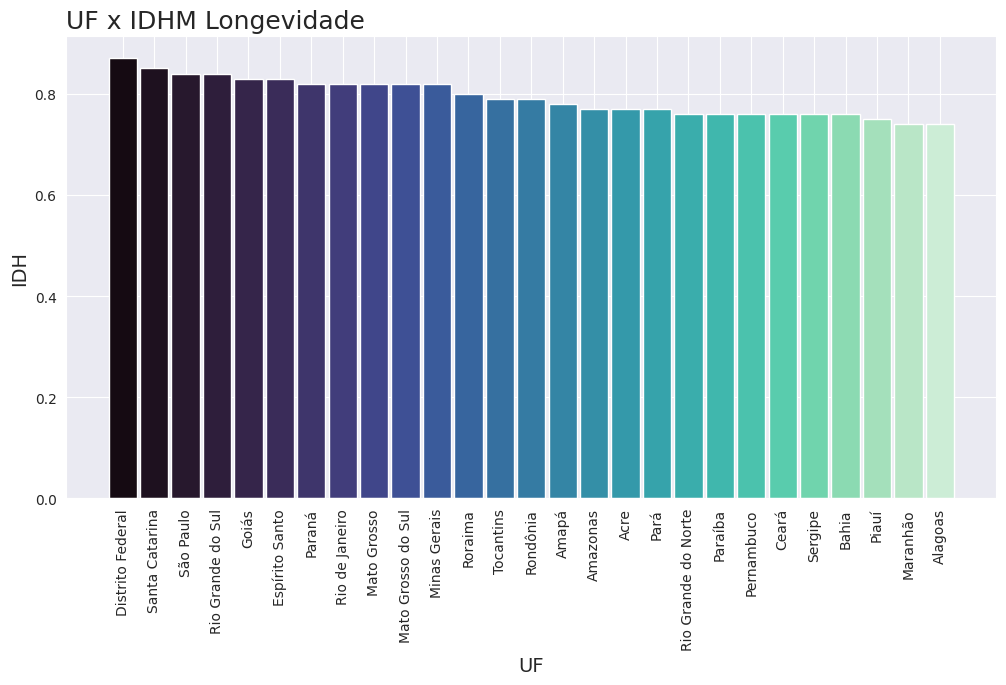

In [62]:
# Ordenar os dados do maior para o menor número de infecções
df_idhm_estado = df_idhm_estado.sort_values(by="idhm_longevidade", ascending=False)

#Tamanho da Figura
plt.figure(figsize=(12,6))

#Paleta de Cores
Paleta_Cores = sns.color_palette('mako', len(df_idhm_estado) )
sns.set_style('darkgrid')

#Plotagem
plt.bar(df_idhm_estado['uf'],
        df_idhm_estado['idhm_longevidade'],
        width=0.9,
        color = Paleta_Cores
        )

#Titulo
plt.title('UF x IDHM Longevidade', loc = 'left', fontsize = 18)

#Labels
plt.xlabel('UF', fontsize = 14)
plt.ylabel('IDH', fontsize = 14)
plt.xticks(rotation = 90);

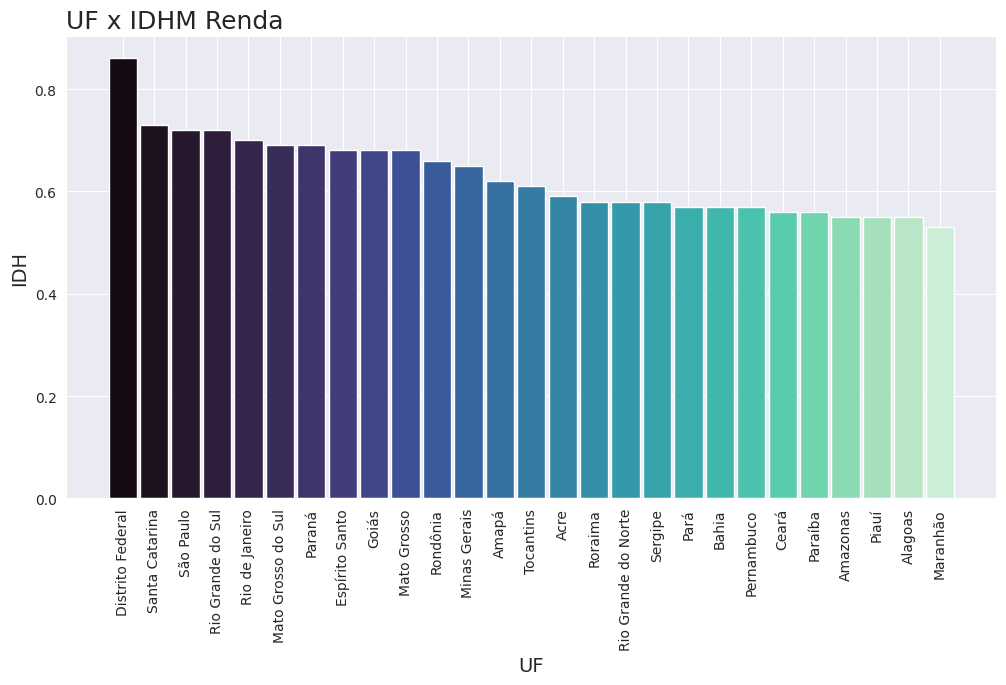

In [63]:
# Ordenar os dados do maior para o menor número de infecções
df_idhm_estado = df_idhm_estado.sort_values(by="idhm_renda", ascending=False)

#Tamanho da Figura
plt.figure(figsize=(12,6))

#Paleta de Cores
Paleta_Cores = sns.color_palette('mako', len(df_idhm_estado) )
sns.set_style('darkgrid')

#Plotagem
plt.bar(df_idhm_estado['uf'],
        df_idhm_estado['idhm_renda'],
        width=0.9,
        color = Paleta_Cores
        )

#Titulo
plt.title('UF x IDHM Renda', loc = 'left', fontsize = 18)

#Labels
plt.xlabel('UF', fontsize = 14)
plt.ylabel('IDH', fontsize = 14)
plt.xticks(rotation = 90);

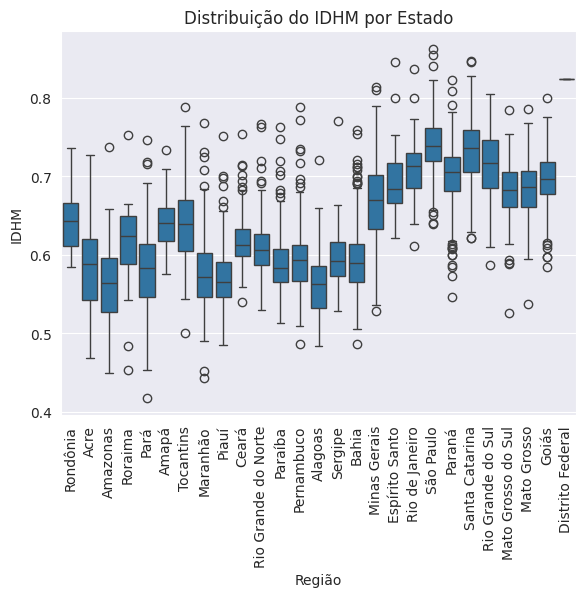

In [64]:
#Boxsplot por estado
plt.figure()
sns.boxplot(data=df_idhm, x="uf", y="idhm") #municipio
plt.title("Distribuição do IDHM por Estado")
plt.xlabel("Região")
plt.ylabel("IDHM")
plt.tight_layout()
plt.xticks(rotation = 90);
plt.show()

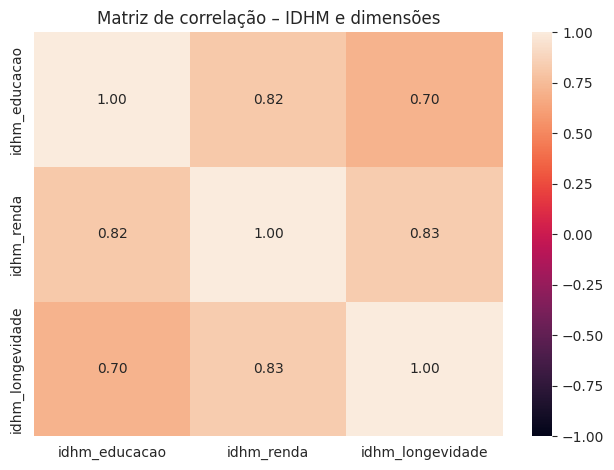

In [65]:
cols_corr = [c for c in ["idhm_educacao", "idhm_renda", "idhm_longevidade"] if c in df_idhm.columns]
corr = df_idhm[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – IDHM e dimensões")
plt.tight_layout()
plt.show()

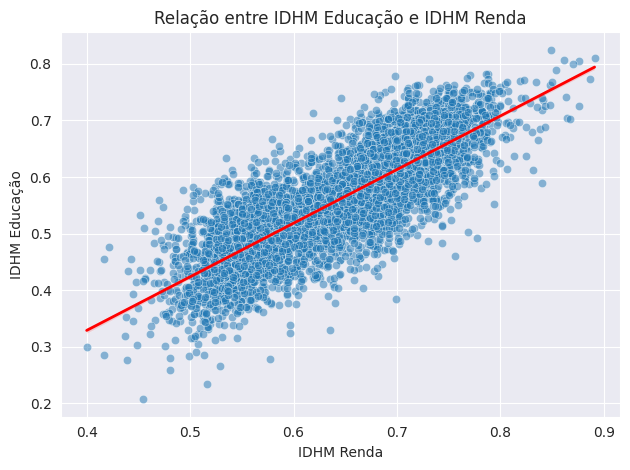

In [66]:
sns.scatterplot(data=df_idhm, x="idhm_renda", y="idhm_educacao", alpha=0.5)

# Linha de tendência com regplot
sns.regplot(
         data=df_idhm,
        x="idhm_renda",
        y="idhm_educacao",
        scatter=False,            # não recria os pontos
        color="red",              # linha de tendência em vermelho
        line_kws={"linewidth": 2} # deixa a linha mais grossa
    )

plt.title("Relação entre IDHM Educação e IDHM Renda")
plt.xlabel("IDHM Renda")
plt.ylabel("IDHM Educação")
plt.tight_layout()
plt.show()